# FaceDetector Processing

---

Tahapan ini mencakup pengambilan, pemrosesan dan evaluasi untuk skenario tugas dan istirahat
- Mengambil data dari file npy
- Melakukan pre-processing pada sinyal rPPG dan PPG
- Melakukan extraksi HR dan HRV (SDNN dan RMSSD)
- Evaluasi MAE, RMSE dan PC

In [101]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import numpy as np


In [102]:
@dataclass
class SignalData:
    subject: str
    task: str
    method: str  
    raw: np.ndarray
    fs: int
    preprocessed: np.ndarray = None


## Preprocessing & Signal Extraction

### Define the processing method (Preprocess, Ekstraksi HR / HRV Metrik Pipeline)
---

In [103]:
def preprocess_rppg(rppg_signal, ppg_signal, fs_rppg=35, fs_ppg=64,):
    # Time bases
    t_rppg = np.arange(len(rppg_signal)) / fs_rppg
    t_ppg  = np.arange(len(ppg_signal)) / fs_ppg

    # Interpolation to PPG Samples Length
    cs = scipy.interpolate.CubicSpline(t_rppg, rppg_signal)
    rppg_up = cs(t_ppg)

    # Bandpass filter rPPG
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    rppg_filtered = scipy.signal.filtfilt(b, a, rppg_up)

    # Normalize signals
    rppg_filtered = (rppg_filtered - np.mean(rppg_filtered)) / np.std(rppg_filtered)

    return rppg_filtered


In [104]:
def preprocess_ppg(ppg_signal, fs_ppg=64):

    # Bandpass filter the PPG signal
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    ppg_filtered = scipy.signal.filtfilt(b, a, ppg_signal)

    # Normalize the signal
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / np.std(ppg_filtered)

    return ppg_filtered


Main Methods

---

Opening the npy files for FaceDetector

In [105]:
root_path = "dataset_numpy"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1", "T3"] # Rest, Task

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

all_signals = []

for subject in subjects:
    for task in tasks:
        # --- Ground truth PPG ---
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        gt_signal = preprocess_ppg(gt_data, fs_ppg=sample_rate_gt)

        all_signals.append(
            SignalData(
                subject=subject,
                task=task,
                method="PPG",
                raw=gt_data,
                fs=sample_rate_gt,
                preprocessed=gt_signal
            )
        )

        # --- rPPG methods ---
        for method in ["POS", "LGI", "OMIT", "GREEN", "CHROM"]:
            file_path = os.path.join(root_path, subject, f"{subject}_{task}_{method}_rppg.npy")
            rppg_raw = np.load(file_path)

            rppg_preproc = preprocess_rppg(rppg_raw, gt_data,
                                           fs_rppg=sample_rate_video,
                                           fs_ppg=sample_rate_gt)

            all_signals.append(
                SignalData(
                    subject=subject,
                    task=task,
                    method=method,
                    raw=rppg_raw,
                    fs=sample_rate_video,
                    preprocessed=rppg_preproc
                )
            )

## Sanity check the pipeline for the result
## Expected all methods should have length of 11520 (64 Hz * 180 sec = 11520 samples long)
summary = pd.DataFrame([{
    "Subject": sig.subject,
    "Task": sig.task,
    "Method": sig.method,
    "RawLen": len(sig.raw),
    "PreprocLen": len(sig.preprocessed)
} for sig in all_signals])

print(summary.head(20))


   Subject Task Method  RawLen  PreprocLen
0      s41   T1    PPG   11520       11520
1      s41   T1    POS    6325       11520
2      s41   T1    LGI    6325       11520
3      s41   T1   OMIT    6325       11520
4      s41   T1  GREEN    6325       11520
5      s41   T1  CHROM    6300       11520
6      s41   T3    PPG   11520       11520
7      s41   T3    POS    6325       11520
8      s41   T3    LGI    6325       11520
9      s41   T3   OMIT    6325       11520
10     s41   T3  GREEN    6325       11520
11     s41   T3  CHROM    6300       11520
12     s42   T1    PPG   11520       11520
13     s42   T1    POS    6325       11520
14     s42   T1    LGI    6325       11520
15     s42   T1   OMIT    6325       11520
16     s42   T1  GREEN    6325       11520
17     s42   T1  CHROM    6300       11520
18     s42   T3    PPG   11520       11520
19     s42   T3    POS    6325       11520


Notes:

---

The signal been in the same length and preprocessed

and it's fine to move on to the HR / HRV Extraction

## Evaluasi Performa rPPG
---

Tahapan ini akan mengukur HR / HRV dari rPPG dan PPG

In [106]:
@dataclass
class MetricData:
    subject: str
    task: str
    method: str
    hr: float
    sdnn: float
    rmssd: float


**Formula Perhitungan HR dan HRV**

**Heart Rate (HR):**
$$
HR = \frac{60}{\overline{RR}}
$$
- $\overline{RR}$ = rata-rata interval RR (detik) antar puncak sinyal

**SDNN (Standard Deviation of NN intervals):**
$$
SDNN = \text{std}(RR_{ms})
$$
- $(RR_{ms})$ = interval RR dalam milidetik

**RMSSD (Root Mean Square of Successive Differences):**
$$
RMSSD = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N-1} (RR_{ms,i+1} - RR_{ms,i})^2}
$$
- $(RR_{ms,i})$ = interval RR ke-i dalam milidetik
- $(N)$ = jumlah interval RR valid

**Langkah:**
1. Deteksi puncak sinyal (peak detection)
2. Hitung interval RR antar puncak: $(RR = \frac{\Delta \text{peak}}{fs})$
3. Bersihkan RR di luar rentang 0.3–2.0 detik
4. Konversi RR ke milidetik: $(RR_{ms} = RR \times 1000)$
5. Hitung HR, SDNN, RMSSD dengan rumus

In [ ]:
## Define the method to compute the metrics
## This method will takes any signal (rPPG, PPG) 
# and it's sampling rate to get the HR and HRv
def compute_metrics(signal, fs):
    ## Compute the HR
    peaks , _ = scipy.signal.find_peaks(signal, prominence=0.5)

    ## Getting the RR Interval / Jeda Waktu antar Puncak / Beat
    rr = np.diff(peaks) / fs  # Convert to unit seconds

    ## Clean the RR
    rr = np.asarray(rr, dtype=float)
    rr_intervals = rr[( rr >= 0.3 ) & (rr <= 2.0)] # Clean RR interval outside 0.3 - 2.0 seconds

    ## Calculating the HR
    hr = int(60 / np.mean(rr_intervals))

    ## Converting RR interval for milis for HRV analysis
    rr_intervals_ms = rr_intervals * 1000  # Convert to milliseconds

    ## Calculating the HRV (SDNN, RMSSD)
    ## Casting to Int for easier interpretation
    sdnn = int(np.std(rr_intervals_ms))
    rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_intervals_ms)))))

    return hr, sdnn, rmssd

**Create a Header Template for HR, HRV**

---

Membuat header template agar tabel lebih padat dan bisa memuat banyak informasi, akan ada 3 tabel (HR, SDNN, RMSSD), dikelompokan berdasarkan 
- Tipe skenario
- Metode pengukuran data

In [108]:
arrays = [
    [""] + ["Rest"]*6 + ["Task"]*6,
    ["Subject", "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM",
     "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
]


columns = pd.MultiIndex.from_arrays(arrays)

In [109]:
all_metrics = []

for sig in all_signals:
    ## Semua sinyal di resample ke 64 Hz
    hr, sdnn, rmssd = compute_metrics(sig.preprocessed, 64) 
    all_metrics.append(MetricData(sig.subject, sig.task, sig.method, hr, sdnn, rmssd))


In [110]:
df_metrics = pd.DataFrame([{
    "Subject": metrics.subject,
    "Task": metrics.task,
    "Method": metrics.method,
    "HR": metrics.hr,
    "SDNN": metrics.sdnn,
    "RMSSD": metrics.rmssd
} for metrics in all_metrics])


#### Ekstraksi HR

---

In [111]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_hr = pd.DataFrame(rows, columns=columns)
df_hr

Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   96   96    88   96   96    95   74   99    74   96   96    97
1      s42   70   71    76   71   71    71   83   89    73   81   82    85
2      s43   95   94    88   92   92    93   84   89    71   84   84    87
3      s44   63   67    67   63   63    67   65   67    64   61   61    71
4      s45   77   76    74   76   76    78   83   83    69   77   76    80
5      s46   74   74    74   74   74    74   88   85    84   85   85    86
6      s47   77   77    72   78   78    78   78   91    62   84   85    90
7      s48   65   72    65   71   71    71   75   82    69   78   77    83
8      s49  101  101    87   99   99   101   70   89    77   84   84    89
9      s50  103  102    89  102  102   102  103  103    81  103  103   100
10     s51   62   62    67   62   62    63   72   75    60   72   72    74
11     s52   78   89    82   89   89    88   74   86    76   84   84    84
12     s53   64   85    82   85   85    85   68   75    73   73   73    75
13     s54   87   93    76   90   90    92   90   90    75   84   84    89
14     s55   88   93    64   89   89    91   86   86    50   41   41    81
15     s56   71   84    68   79   79    80   75   82    76   80   80    84

#### Evaluasi HR (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai HR antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran HR dari rPPG dan PPG.

In [112]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_hr[(cond, "GT")]  # ground truth for condition rest / task
    for method in methods:
        row=[method]
        pred = df_hr[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_hr = pd.DataFrame(eval_results)
print("HR (satuan: BPM)")
eval_df_hr

HR (satuan: BPM)


,Condition,Method,MAE,RMSE,PC
0,Rest,POS,4.4375,7.335700,0.890876
1,Rest,GREEN,7.8750,10.191909,0.698441
2,Rest,LGI,3.6875,6.562202,0.897551
3,Rest,OMIT,3.6875,6.562202,0.897551
4,Rest,CHROM,4.1250,6.698881,0.908825
5,Task,POS,6.8125,9.775607,0.667658
6,Task,GREEN,10.2500,13.697628,0.250453
7,Task,LGI,8.1875,13.695346,0.321868
8,Task,OMIT,8.1875,13.736357,0.322018
9,Task,CHROM,7.1875,9.450529,0.600982


**Visualisasi Hasil MAE, RMSE dan PC**

---

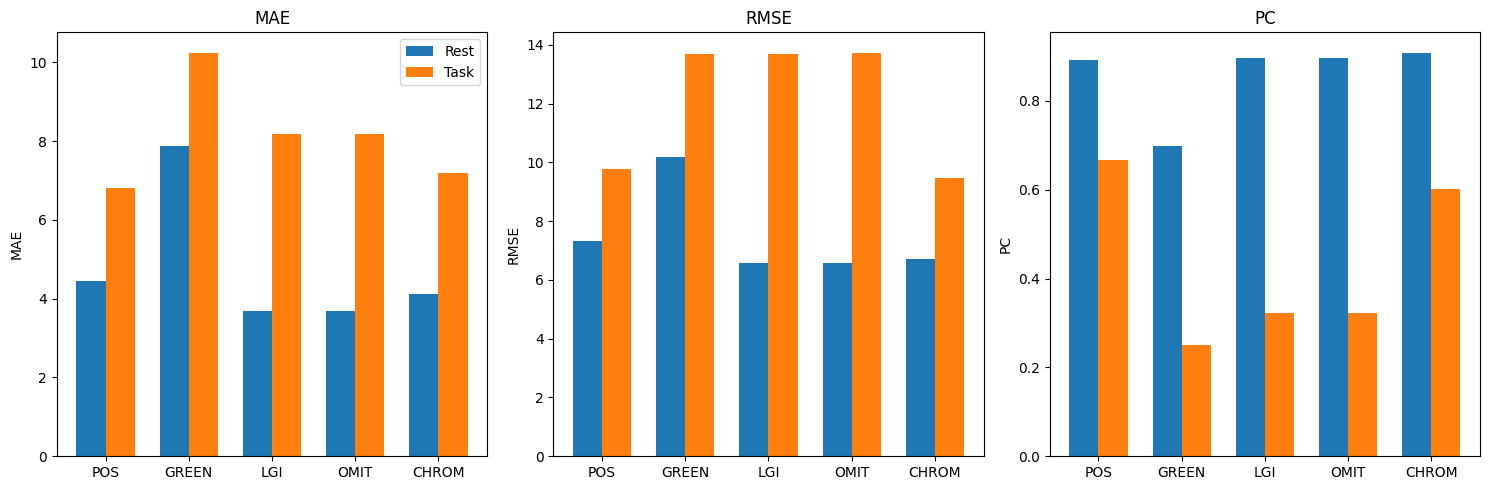

In [113]:
metrics = ["MAE", "RMSE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_hr[eval_df_hr["Condition"]=="Rest"][metric]
    task_vals = eval_df_hr[eval_df_hr["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 4.4375     | 7.335700    | 0.890876  | 6.8125     | 9.775607    | 0.667658  |
| GREEN  | 7.8750     |10.191909    | 0.698441  |10.2500     |13.697628    | 0.250453  |
| LGI    | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.695346    | 0.321868  |
| OMIT   | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.736357    | 0.322018  |
| CHROM  | 4.1250     | 6.698881    | 0.908825  | 7.1875     | 9.450529    | 0.600982  |

**Observation**

---

- Pada kondisi istirahat, rPPG dapat mengukur HR (detak jantung) dengan cukup stabil dan konsistensi yang tinggi terhadap hasil HR dari PPG, dengan nilai MAE < 5 (stabilitas) dan PC > 0.8 (konsistensi) baik.
- Sebaliknya, pada tugas mental, pengukuran HR (detak jantung) relatif kurang stabil dengan error yang meningkat (MAE dan RMSE lebih tinggi), dan korelasi (PC) yang menurun, menandakan reliabilitas rPPG berkurang dalam mengukur detak jantung (HR), karena pada tugas mental, tidak sepenuhnya subjek diam, penurunan performa ini kemungkinan disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi dibandingkan saat kondisi istirahat, dimana subjek relatif diam. 
- Secara umum, dalam studi biomedis, MAE < 5 bpm dan RMSE < 8 bpm dianggap cukup baik untuk estimasi HR dari video, serta PC > 0.8 (baik) dan > 0.6 (moderat) [[0]](https://biomedical-engineering-online.biomedcentral.com/articles/10.1186/s12938-025-01405-5?utm_source=chatgpt.com).
- Dari hasil evaluasi, metode POS dan CHROM terbukti paling robust di kedua skenario (Rest dan Task), dengan error rendah dan konsistensi tren pengukuran HR terhadap PPG (PC > 0.6, kategori moderat hingga baik).

#### Ekstraksi HRV (SDNN)

In [114]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_sdnn = pd.DataFrame(rows, columns=columns)
print("SDNN (Satuan: ms)")
df_sdnn


SDNN (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   54   59   181   69   69    92  264   98   264  133  132   128
1      s42  110   99   237  109  111   139  185  183   290  247  238   214
2      s43   45   51   169  100  100    76  178  149   307  194  186   159
3      s44  141  203   253  177  176   223  220  180   322  220  220   221
4      s45  100   82   269  110  110   130  115  149   301  229  233   209
5      s46   59   59    66   59   59    80  104  143   255  177  186   151
6      s47   90   74   204  106  107   109  281  109   322  193  188   129
7      s48  314   91   267  122  122   111  300  155   310  234  236   193
8      s49   44   42   237   98   98    55  313  154   273  213  216   156
9      s50   28   38   217   49   49    66   86   69   257   78   82   117
10     s51   80   86   213   83   83   125  139  133   343  159  159   179
11     s52  190   96   210  104  104   121  237  133   272  163  161   159
12     s53  114  142   200  143  143   153  265  134   268  135  132   166
13     s54  152   56   269  126  126    80  117  117   278  215  213   140
14     s55  166  117   368  149  149   142  130  129   265   46   46   199
15     s56  312  123   359  179  183   206  262  174   296  208  209   178

#### Evaluasi SDNN (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai SDNN antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran SDNN dari rPPG dan PPG.

In [115]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_sdnn[(cond, "GT")]  # ground truth for condition rest / task
    for method in methods:
        row=[method]
        pred = df_sdnn[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_sdnn = pd.DataFrame(eval_results)
eval_df_sdnn

,Condition,Method,MAE,RMSE,PC
0,Rest,POS,50.9375,83.453954,0.453787
1,Rest,GREEN,113.3750,127.266944,0.620736
2,Rest,LGI,43.3750,67.093219,0.668770
3,Rest,OMIT,43.1250,66.585471,0.675890
4,Rest,CHROM,53.5625,70.599664,0.549925
5,Task,POS,70.8125,95.070697,0.270546
6,Task,GREEN,94.1875,116.254301,0.171312
7,Task,LGI,69.8750,80.662104,0.310962
8,Task,OMIT,69.5625,81.417520,0.293811
9,Task,CHROM,72.8750,86.868435,-0.010865


**Visualisasi Hasil MAE, RMSE dan PC**

---

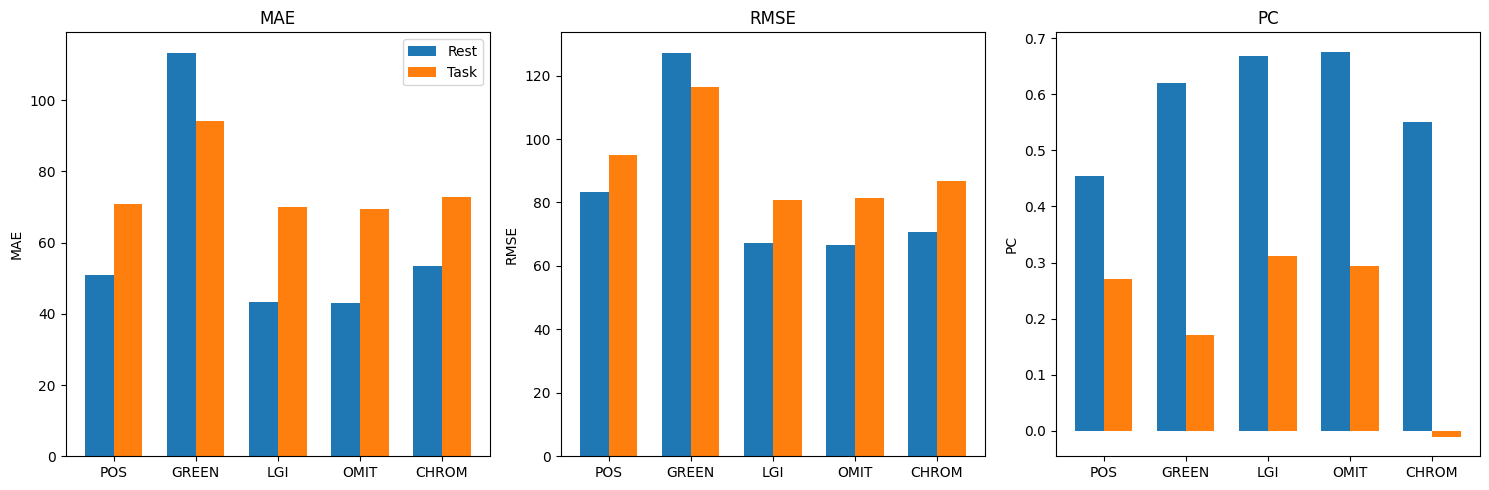

In [116]:
metrics = ["MAE", "RMSE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Rest"][metric]
    task_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 50.89      | 83.41       | 0.4546    | 70.89      | 95.17       | 0.2672    |
| GREEN  |113.42      |127.37       | 0.6198    | 94.20      |116.28       | 0.1734    |
| LGI    | 43.35      | 66.98       | 0.6697    | 69.93      | 80.68       | 0.3106    |
| OMIT   | 43.06      | 66.51       | 0.6768    | 69.84      | 81.59       | 0.2907    |
| CHROM  | 53.64      | 70.66       | 0.5486    | 72.87      | 86.82       | -0.0077   |

**Observation**

---

- HRV adalah ukuran variasi waktu antar detak jantung, sehingga membutuhkan ketelitian waktu yang lebih tinggi dibandingkan hanya menghitung rata-rata detak jantung (HR).

- Dalam evaluasi, HRV (misal SDNN) menunjukkan seberapa besar fluktuasi interval antar detak, bukan hanya jumlah detak per menit. Oleh karena itu, kualitas sinyal dan akurasi deteksi puncak sangat penting agar hasil HRV

- Pengukuran HRV seperti ini biasanya menggunakan metode kontak (EKG / PPG) yang memiliki error yang lebih rendah (MAE < 10ms) yang cocok dipakai.

- rPPG sebagai metode kontak tentu akan menghadapi error tambahan seperti delay, noise, dan aftifak gerakan. Penelitian sebelumnya berfokus pada pengukuran HRV melaporkan error SDNN / RMSSD 10 - 40 ms (Perbedaan dengan metode kontak PPG) [[1]](https://www.mdpi.com/2306-5354/10/7/851)[[2]](https://arxiv.org/pdf/2305.04161). Penggunaan korelasi (PC) juga digunakan untuk menilai konsistensi pengukuran SDNN ini.

- Pada kondisi istirahat, sama seperti pengukuran detak jantung, beberapa metode rPPG masih dapat mencapai korelasi moderat (PC > 0.6), meskipun MAE relatif tinggi (> 30–40 ms). Hal ini menunjukan rPPG dapat melakukan pengukuran HRV meskipun cederung overestimasi (dengan error yang relatif tinggi).

- Kondisi tugas/mental load: performa memburuk lebih jauh (MAE/RMSE meningkat, PC < 0.3), sehingga estimasi HRV tidak konsisten dengan referensi kontak. Penurunan performa ini disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi sama seperti pengukuran HR

- Kesimpulan: saat ini, rPPG belum cukup andal untuk mengukur nilai absolut HRV (seperti SDNN) di berbagai kondisi. Namun, pada skenario minim gerakan, rPPG masih bisa digunakan untuk memantau tren relatif (apakah HRV naik/turun) dibandingkan ground truth. Untuk mencapai presisi yang mendekati metode kontak, diperlukan pendekatan rekonstruksi sinyal yang lebih canggih 

- Namun secara general rPPG masih belum bisa untuk menangkap detail variabilitas detak jantung yang membutuhkan presisi tingkat lanjut serta reliabilitas yang masih kurang (Pearson Corr yang lemah)

#### Ekstraksi HRV (RMSSD)

---

In [117]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_rmssd = pd.DataFrame(rows, columns=columns)
print("RMSSD (Satuan: ms)")
df_rmssd

RMSSD (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   64   64   241   86   85   125  348  132   358  180  181   173
1      s42  128   88   296  123  117   195  235  239   407  331  320   286
2      s43   53   68   239  145  141   113  243  205   398  264  259   221
3      s44  149  212   316  198  195   303  283  215   403  283  282   258
4      s45  145  116   344  149  149   188  155  213   410  330  334   296
5      s46   58   62    74   60   60   102  116  178   313  240  246   212
6      s47  104   69   273  132  134   148  335  139   405  255  243   158
7      s48  362   90   382  158  157   161  426  195   379  316  323   236
8      s49   47   39   346  135  135    65  428  199   339  296  309   219
9      s50   20   46   311   64   64    95   97   91   343  108  111   163
10     s51   91  100   244   86   86   160  177  162   458  211  211   239
11     s52   99  107   283  125  125   161  311  165   367  220  215   224
12     s53  157   87   243   93   93   129  345  159   350  163  153   221
13     s54  187   80   357  185  185   109  154  164   391  290  288   199
14     s55  207  140   452  199  184   193  153  172   302   93   93   262
15     s56  440  171   458  252  256   274  353  238   405  270  269   236

#### Evaluasi RMSSD (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai RMSSD antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran RMSSD dari rPPG dan PPG.

In [118]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_rmssd[(cond, "GT")]  # ground truth for condition rest / task
    for method in methods:
        row=[method]
        pred = df_rmssd[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_rmssd = pd.DataFrame(eval_results)
eval_df_rmssd

,Condition,Method,MAE,RMSE,PC
0,Rest,POS,63.8750,104.864198,0.558860
1,Rest,GREEN,159.2500,180.077761,0.663895
2,Rest,LGI,51.9375,80.499612,0.738899
3,Rest,OMIT,52.6875,79.934739,0.752105
4,Rest,CHROM,74.0000,90.423310,0.585773
5,Task,POS,99.9375,130.868493,0.240065
6,Task,GREEN,133.8125,160.211774,0.071894
7,Task,LGI,93.9375,109.394070,0.302949
8,Task,OMIT,94.1250,109.997159,0.300513
9,Task,CHROM,106.0000,120.748188,-0.103513


**Visualisasi Hasil MAE, RMSE dan PC**

---

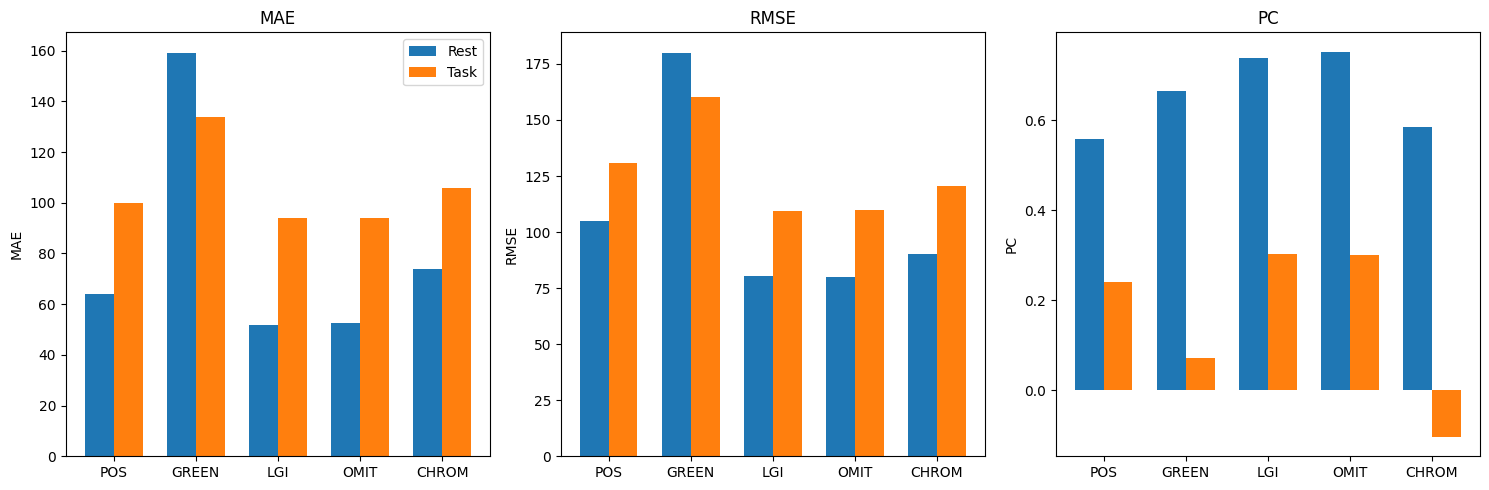

In [119]:
metrics = ["MAE", "RMSE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Rest"][metric]
    task_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 63.88      |104.86       | 0.5589    | 99.94      |130.87       | 0.2401    |
| GREEN  |159.25      |180.08       | 0.6639    |133.81      |160.21       | 0.0719    |
| LGI    | 51.94      | 80.50       | 0.7389    | 93.94      |109.39       | 0.3029    |
| OMIT   | 52.69      | 79.93       | 0.7521    | 94.13      |110.00       | 0.3005    |
| CHROM  | 74.00      | 90.42       | 0.5858    |106.00      |120.75       | -0.1035   |

**Observation**

---

- RMSSD adalah metrik HRV yang mengukur variasi jeda waktu antar detak jantung. Seperti SDNN, RMSSD membutuhkan ketelitian waktu tinggi karena fokusnya pada perubahan waktu antar detak, bukan hanya jumlah detak.
- Pada kondisi tugas mental, performa rPPG menurun, baik dari sisi error maupun konsistensi pola (Pearson Correlation).
- Secara umum, rPPG kurang cocok untuk mengukur HRV secara non-kontak di berbagai skenario karena sangat sensitif terhadap gerakan dan pencahayaan, sehingga presisi hasil HRV sulit

### Overall Checks: Visualisasi Hasil MAE, RMSE, dan PC

---

Evaluasi awal dilakukan untuk menilai sejauh mana metode rPPG mampu merekonstruksi sinyal fisiologis dibandingkan sinyal referensi PPG. Penilaian dilakukan pada dua skenario (Rest dan Task) dengan tiga metrik utama: HR, SDNN, dan RMSSD. Setiap metode rPPG dievaluasi menggunakan indikator statistik (MAE, RMSE, dan Pearson Correlation).

Hasil evaluasi ini menjadi dasar untuk:
1. Menentukan metode rPPG yang relatif paling konsisten pada kedua skenario.  
2. Mengidentifikasi metrik fisiologis yang lebih stabil untuk digunakan pada tahap analisis berikutnya.  

Secara umum, **HR menunjukkan kecenderungan lebih reliabel** dibanding SDNN dan RMSSD, dengan performa lebih baik pada MAE, RMSE, dan PC. Di antara metode rPPG, **POS dan CHROM tampil lebih konsisten terutama pada estimasi HR**, meskipun performa estimasi HRV masih bervariasi dan dari hasil pengukuran, error yang dihasilkan masih cukup tinggi untuk dapat digunakan sebagai alternatif.

Berdasarkan hal ini, analisis selanjutnya difokuskan pada **HR** sebagai metrik utama. Fokus ini tidak hanya karena keunggulan teknis (error lebih rendah), tetapi juga karena HR lebih relevan sebagai indikator fisiologis terhadap peningkatan beban mental. Dengan demikian, tahap berikutnya akan memvisualisasikan perbedaan antara kondisi Rest dan Task pada level kelompok maupun individu.


## Analisis : Tugas Istirahat vs Tugas Mental

---

Analisis perbandingan kondisi istirahat (Rest) dan tugas mental (Task) difokuskan pada dua metrik utama, yaitu HR (Heart Rate) dan HRV (Heart Rate Variability). Dari hasil evaluasi, HR merupakan metrik yang paling reliabel untuk diestimasi menggunakan rPPG, sehingga interpretasi utama akan menekankan pada perubahan HR antar kondisi. 

Sementara itu, HRV juga tetap ditampilkan untuk memberikan gambaran pola fisiologis yang lebih lengkap, meskipun hasil estimasi dengan rPPG menunjukkan variasi yang lebih tinggi dan konsistensinya lebih rendah dibandingkan PPG. 

Visualisasi berikut akan menunjukkan bagaimana perubahan HR terjadi antara kondisi Rest dan Task, baik pada level kelompok maupun individu, serta ringkasan perubahan HRV yang diamati.

---


### Analisis Tingkat Kelompok

Melihat pengaruh kondisi tugas terhadap peningkatan HR secara keseluruhan pada kelompok subjek.

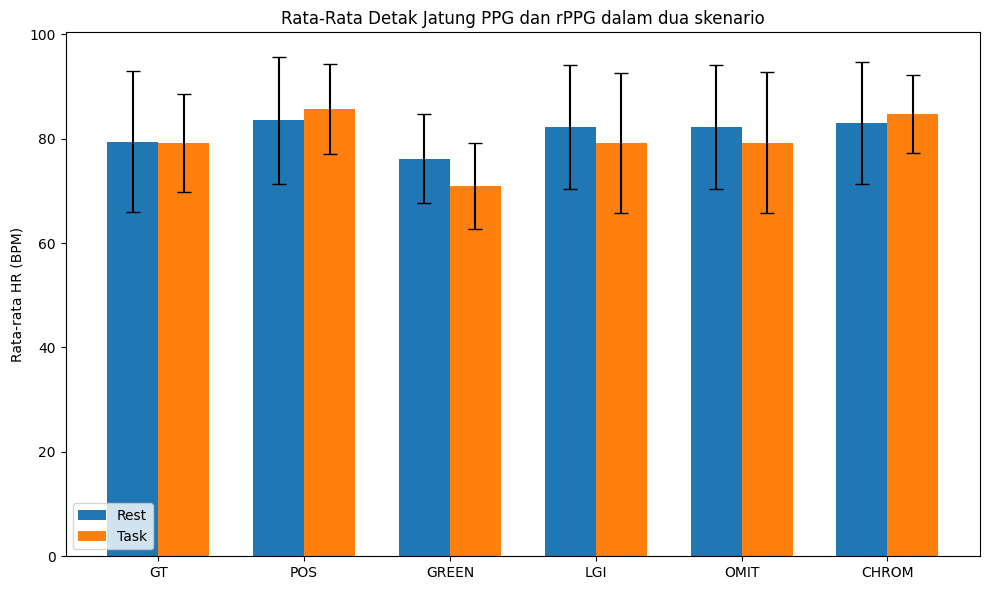

In [120]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_hr[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Rata-rata HR (BPM)")
ax.set_title("Rata-Rata Detak Jatung PPG dan rPPG dalam dua skenario")
ax.legend()
plt.tight_layout()
plt.show()

In [121]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_hr[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,79.4375,13.885094,79.2500,9.705668
POS,83.5000,12.489996,85.6875,8.829638
GREEN,76.1875,8.810742,70.8750,8.515672
LGI,82.2500,12.336936,79.1875,13.876689
OMIT,82.2500,12.336936,79.1875,13.934220
CHROM,83.0625,12.074595,84.6875,7.717675


**Observasi dan Analisis**

---

- Berdasarkan data rata-rata (mean) dan standar deviasi (STD) detak jantung dari metode kontak (PPG/GT), tidak ditemukan perbedaan signifikan antara kondisi istirahat (Rest) dan tugas mental (Task). Nilai rata-rata HR hampir sama (Rest: 79.44 bpm, Task: 79.25 bpm).

- Studi lebih lanjut dengan jumlah data yang lebih besar diperlukan agar efek statistik dapat terlihat lebih jelas.

- Metode rPPG cenderung menghasilkan estimasi pengukuran HR yang lebih tinggi (overestimasi) atau lebih rendah (underestimasi) dibandingkan GT, dengan rata-rata HR yang relatif tinggi pada kedua skenario.

- Karena secara statistik belum terlihat perbedaan yang jelas, analisis intrasubjek diperlukan untuk mengetahui apakah PPG dan rPPG mampu menangkap perubahan fisiologis individu saat mengalami beban mental.

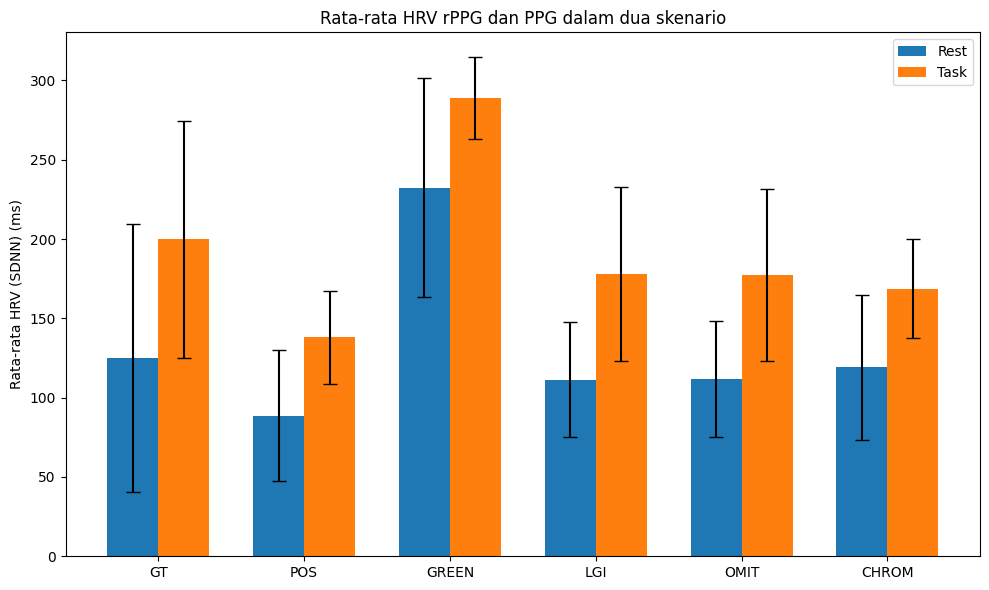

In [122]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_sdnn[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Rata-rata HRV (SDNN) (ms)")
ax.set_title("Rata-rata HRV rPPG dan PPG dalam dua skenario")
ax.legend()
plt.tight_layout()
plt.show()

In [123]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_sdnn[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,124.9375,87.013002,199.7500,76.993073
POS,88.6250,42.678449,138.0625,30.206994
GREEN,232.4375,71.217946,288.9375,26.509039
LGI,111.4375,37.643891,177.7500,56.639798
OMIT,111.8125,38.003892,177.3125,56.050833
CHROM,119.2500,47.130316,168.6250,32.157684


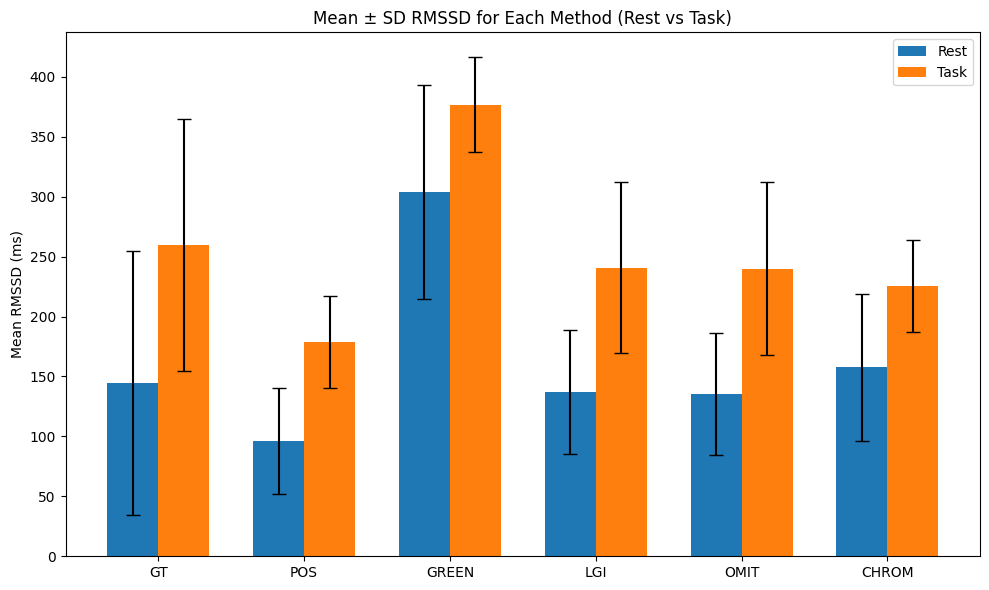

In [124]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_rmssd[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Mean RMSSD (ms)")
ax.set_title("Mean ± SD RMSSD for Each Method (Rest vs Task)")
ax.legend()
plt.tight_layout()
plt.show()

In [125]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_rmssd[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,144.4375,113.930370,259.9375,108.618886
POS,96.1875,45.776586,179.1250,39.646564
GREEN,303.6875,92.357796,376.7500,40.779897
LGI,136.8750,53.233918,240.6250,73.548057
OMIT,135.3750,52.669884,239.8125,74.371337
CHROM,157.5625,63.352947,225.1875,39.672356


**Notes**

Hasil perhitungan HRV (SDNN/RMSSD) menunjukkan bahwa nilai HRV justru meningkat pada kondisi Task dibandingkan Rest, baik pada data GT maupun sebagian metode rPPG. Pola ini berbeda dengan teori psikofisiologi, yang biasanya memperkirakan HRV menurun saat beban mental meningkat. Perbedaan ini kemungkinan muncul karena durasi tugas yang singkat, perbedaan respons tiap individu, atau adanya noise pada estimasi HRV dari rPPG.

Dibutuhkan analisis intrasubjek untuk melihat efek ini lebih dekat


### Analisis Intrasubjek

Melihat bagaimana Respons Individu terhadap Pengaruh tugas istirahat dan mental

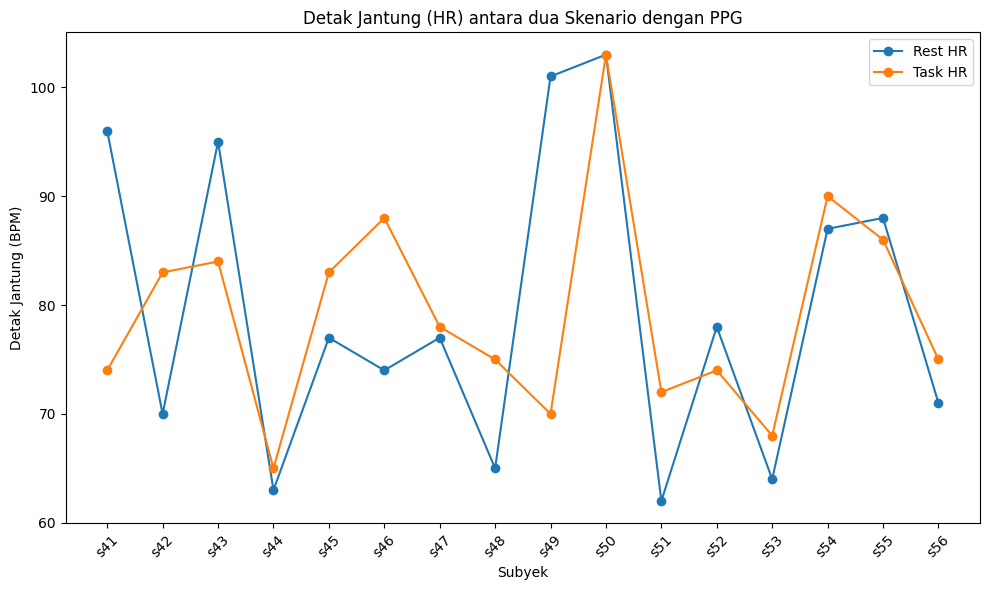

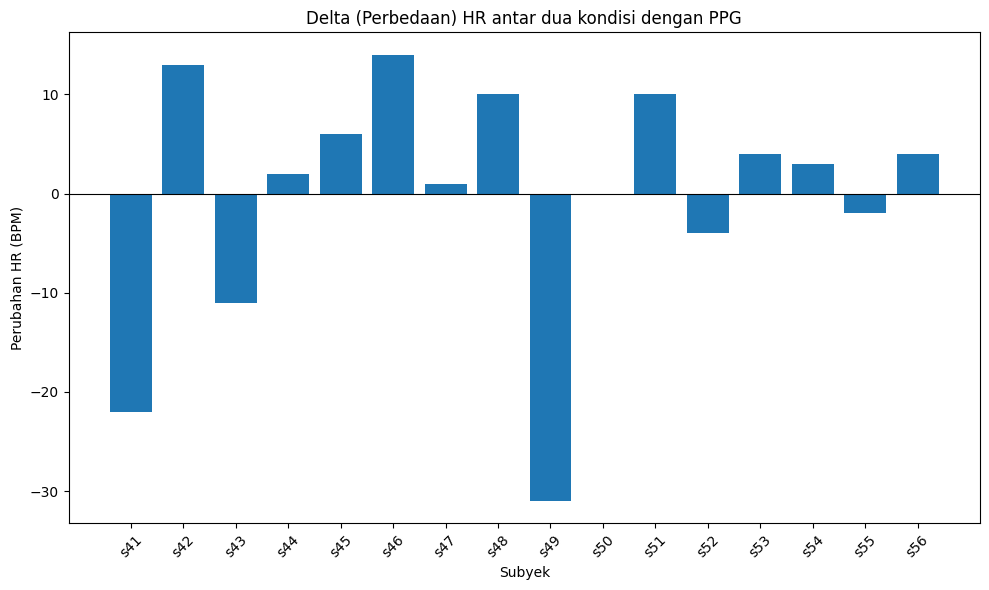

,Subject,Rest_GT,Task_GT,Delta_GT
0,s41,96,74,-22
1,s42,70,83,13
2,s43,95,84,-11
3,s44,63,65,2
4,s45,77,83,6
5,s46,74,88,14
6,s47,77,78,1
7,s48,65,75,10
8,s49,101,70,-31
9,s50,103,103,0


In [ ]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "GT")].values
task_hr = df_hr[("Task", "GT")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_GT": rest_hr,
    "Task_GT": task_hr,
    "Delta_GT": delta_hr
})

fig = plt.figure(figsize=(10, 6))

## Line Chart
plt.plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HR")
plt.plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HR")
plt.title("Detak Jantung (HR) antara dua Skenario dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Detak Jantung (BPM)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_GT"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Delta (Perbedaan) HR antar dua kondisi dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Perubahan HR (BPM)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_GT","Task_GT","Delta_GT"]]

**Metode POS**

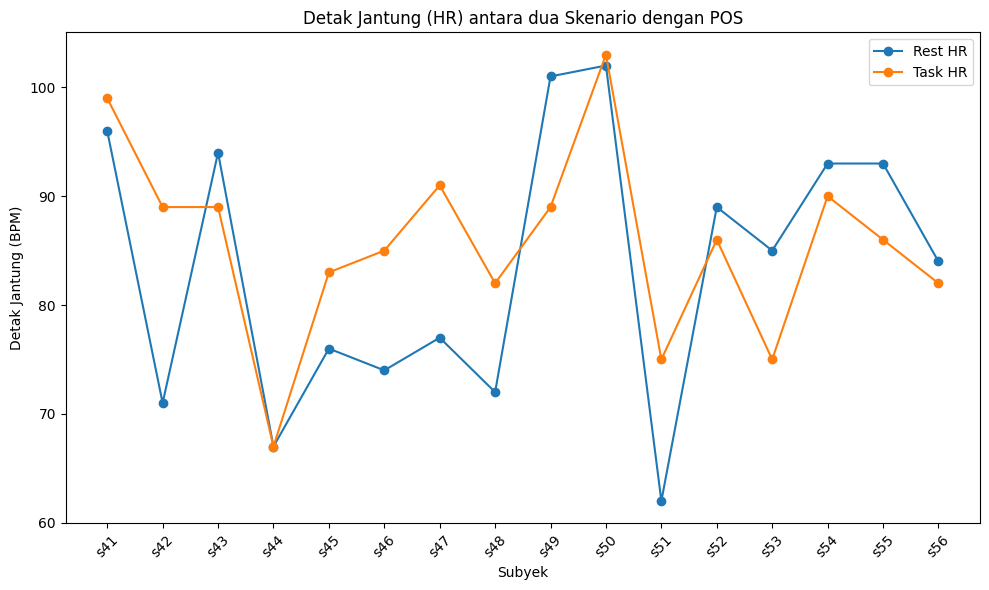

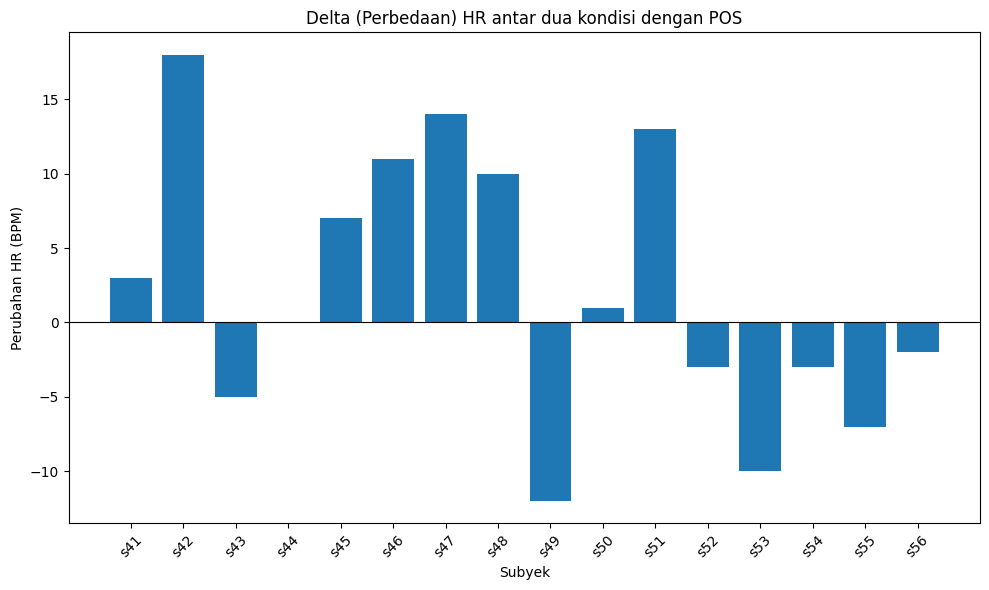

,Subject,Rest_POS,Task_POS,Delta_POS
0,s41,96,99,3
1,s42,71,89,18
2,s43,94,89,-5
3,s44,67,67,0
4,s45,76,83,7
5,s46,74,85,11
6,s47,77,91,14
7,s48,72,82,10
8,s49,101,89,-12
9,s50,102,103,1


In [ ]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "POS")].values
task_hr = df_hr[("Task", "POS")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_POS": rest_hr,
    "Task_POS": task_hr,
    "Delta_POS": delta_hr
})


## Line Chart
plt.figure(figsize=(10, 6))
plt.plot(df_ind["Subject"], df_ind["Rest_POS"], marker="o", label="Rest HR")
plt.plot(df_ind["Subject"], df_ind["Task_POS"], marker="o", label="Task HR")
plt.title("Detak Jantung (HR) antara dua Skenario dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Detak Jantung (BPM)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_POS"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Delta (Perbedaan) HR antar dua kondisi dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Perubahan HR (BPM)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_POS","Task_POS","Delta_POS"]]

**Metode CHROM**

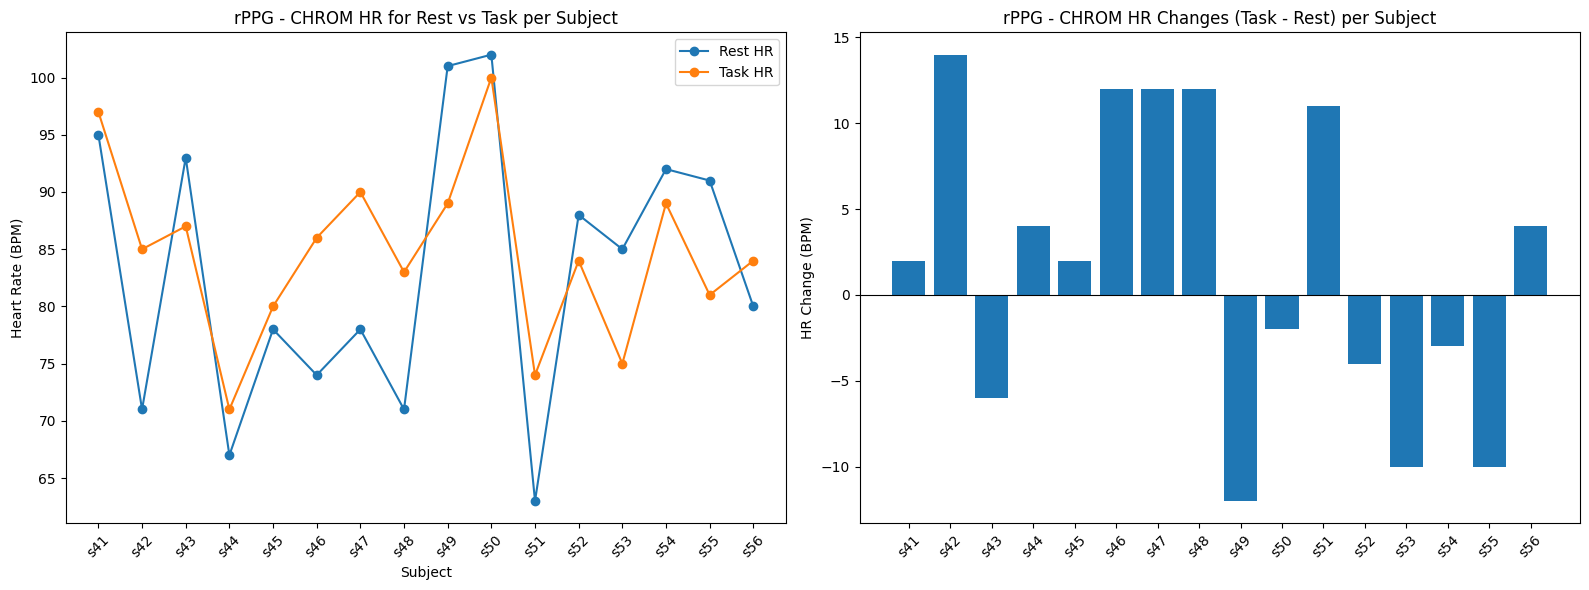

,Subject,Rest_CHROM,Task_CHROM,Delta_CHROM
0,s41,95,97,2
1,s42,71,85,14
2,s43,93,87,-6
3,s44,67,71,4
4,s45,78,80,2
5,s46,74,86,12
6,s47,78,90,12
7,s48,71,83,12
8,s49,101,89,-12
9,s50,102,100,-2


In [128]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "CHROM")].values
task_hr = df_hr[("Task", "CHROM")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_CHROM": rest_hr,
    "Task_CHROM": task_hr,
    "Delta_CHROM": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_CHROM"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_CHROM"], marker="o", label="Task HR")
axes[0].set_title("rPPG - CHROM HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_CHROM"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("rPPG - CHROM HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_CHROM","Task_CHROM","Delta_CHROM"]]

### Konsistensi Pola antara GT & rPPG

- Secara individu, baik data PPG maupun rPPG saat mengukur HR (detak jantung) menunjukkan variasi respons yang berbeda ketika subjek berada dalam beban mental.

- Sebagian subjek mengalami peningkatan detak jantung, sementara yang lain mengalami penurunan, baik pada plot data HR menggunakan metode kontak (PPG) maupun non-kontak (rPPG, POS dan CHROM) yang relatif stabil terhadap tugas mental.

- Hal ini mendukung teori psikofisiologis bahwa respons individu terhadap beban mental memang bervariasi secara fisiologis, namun diperlukan data lebih banyak agar efek statistik dapat terlihat lebih

### HRV

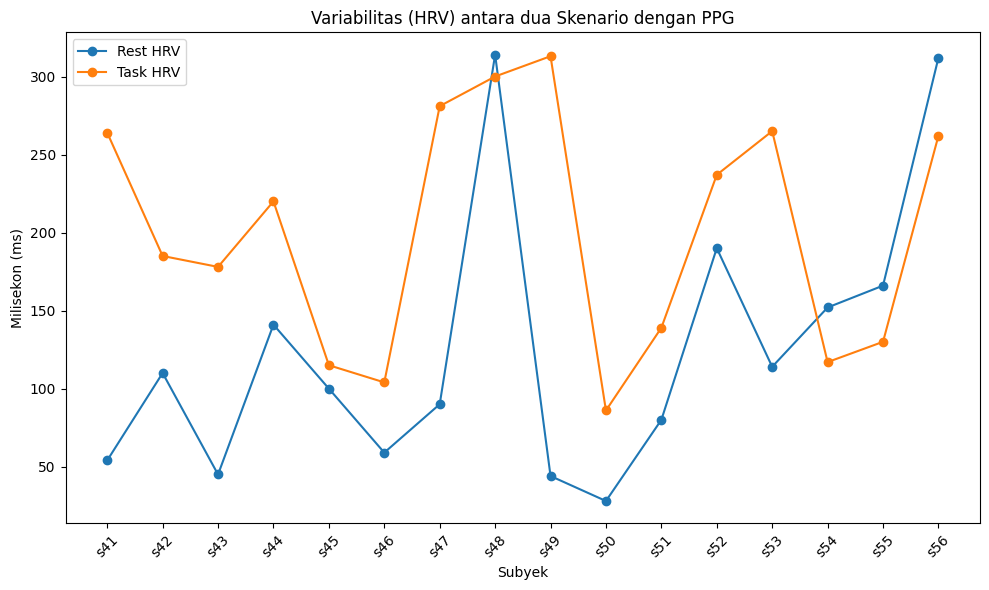

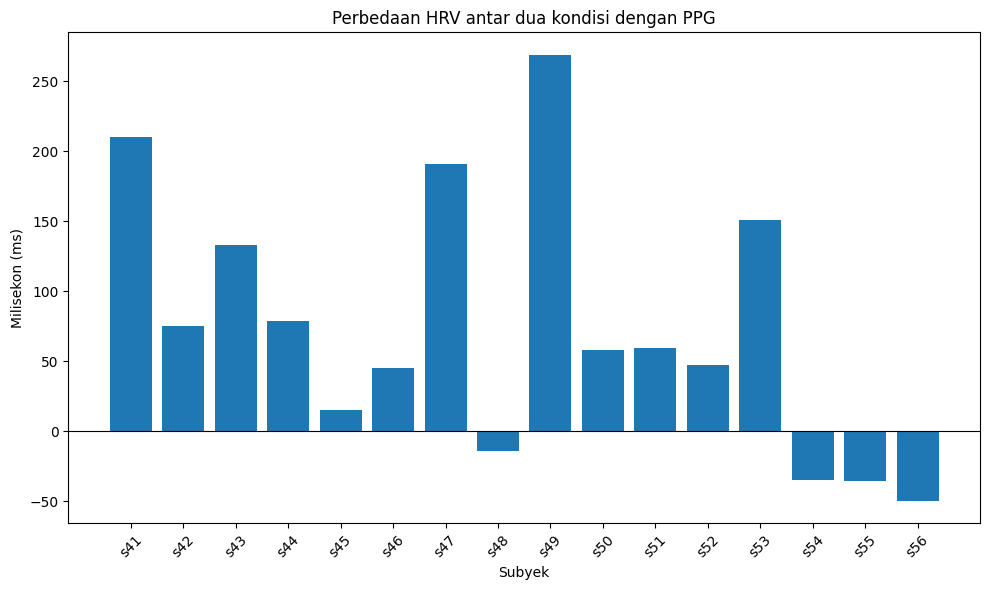

,Subject,Rest_GT,Task_GT,Delta_GT
0,s41,54,264,210
1,s42,110,185,75
2,s43,45,178,133
3,s44,141,220,79
4,s45,100,115,15
5,s46,59,104,45
6,s47,90,281,191
7,s48,314,300,-14
8,s49,44,313,269
9,s50,28,86,58


In [129]:
subjects = df_sdnn[("", "Subject")].values if ("", "Subject") in df_sdnn.columns else df_sdnn.index
rest_sdnn = df_sdnn[("Rest", "GT")].values
task_sdnn = df_sdnn[("Task", "GT")].values
delta_sdnn = task_sdnn - rest_sdnn

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_GT": rest_sdnn,
    "Task_GT": task_sdnn,
    "Delta_GT": delta_sdnn
})

## Line Chart
plt.figure(figsize=(10, 6))
plt.plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HRV")
plt.plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HRV")
plt.title("Variabilitas (HRV) antara dua Skenario dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_GT"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Perbedaan HRV antar dua kondisi dengan PPG")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # Line chart
# axes[0].plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HRV")
# axes[0].plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HRV")
# axes[0].set_title("GT HRV for Rest vs Task per Subject")
# axes[0].set_xlabel("Subject")
# axes[0].set_ylabel("HRV")
# axes[0].legend()
# axes[0].tick_params(axis='x', rotation=45)

# # Bar chart
# axes[1].bar(df_ind["Subject"], df_ind["Delta_GT"])
# axes[1].axhline(0, color="black", linewidth=0.8)
# axes[1].set_title("GT HR Changes (Task - Rest) per Subject")
# axes[1].set_ylabel("HRV")
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

df_ind[["Subject","Rest_GT","Task_GT","Delta_GT"]]

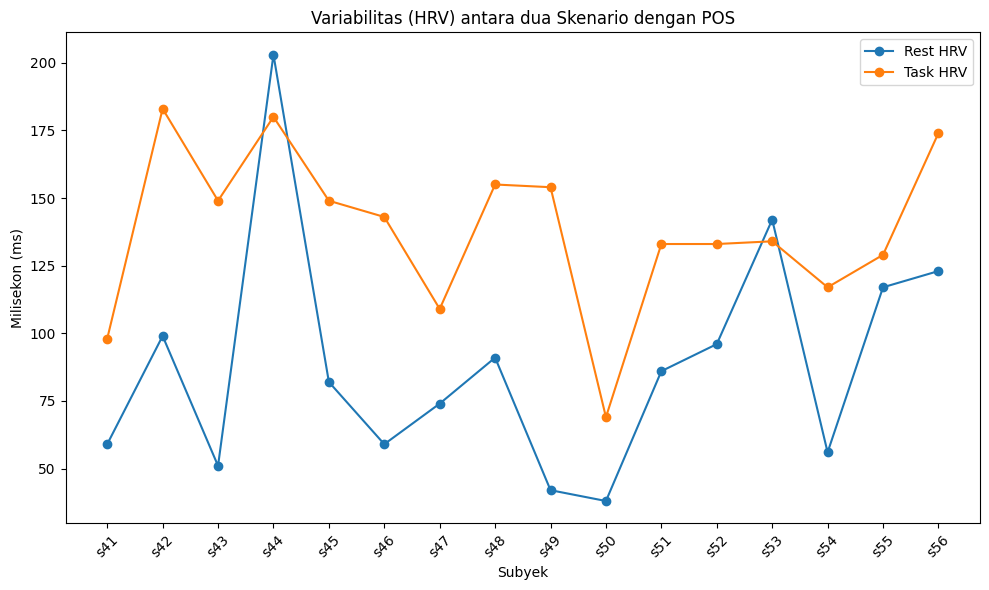

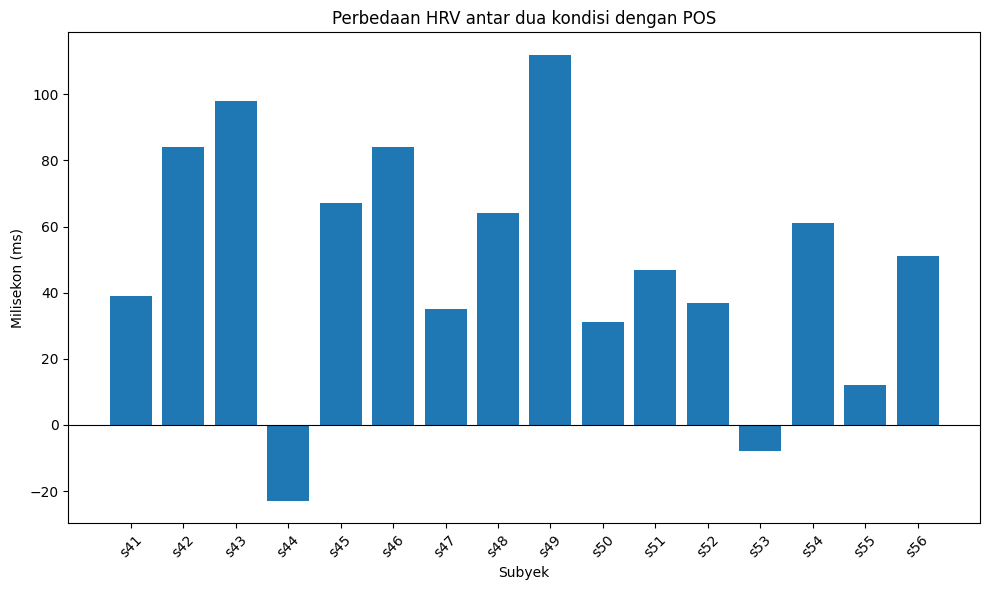

,Subject,Rest_POS,Task_POS,Delta_POS
0,s41,59,98,39
1,s42,99,183,84
2,s43,51,149,98
3,s44,203,180,-23
4,s45,82,149,67
5,s46,59,143,84
6,s47,74,109,35
7,s48,91,155,64
8,s49,42,154,112
9,s50,38,69,31


In [130]:
subjects = df_sdnn[("", "Subject")].values if ("", "Subject") in df_sdnn.columns else df_sdnn.index
rest_sdnn = df_sdnn[("Rest", "POS")].values
task_sdnn = df_sdnn[("Task", "POS")].values
delta_sdnn = task_sdnn - rest_sdnn

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_POS": rest_sdnn,
    "Task_POS": task_sdnn,
    "Delta_POS": delta_sdnn
})

plt.figure(figsize=(10, 6))
plt.plot(df_ind["Subject"], df_ind["Rest_POS"], marker="o", label="Rest HRV")
plt.plot(df_ind["Subject"], df_ind["Task_POS"], marker="o", label="Task HRV")
plt.title("Variabilitas (HRV) antara dua Skenario dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(df_ind["Subject"], df_ind["Delta_POS"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Perbedaan HRV antar dua kondisi dengan POS")
plt.xlabel("Subyek")
plt.ylabel("Milisekon (ms)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_POS","Task_POS","Delta_POS"]]

**Notes**

Menariknya, hasil HRV pada penelitian ini menunjukkan tren peningkatan pada kondisi Task dibanding Rest, baik pada GT maupun estimasi rPPG. Pola ini bertentangan dengan temuan psikofisiologi yang umumnya melaporkan penurunan HRV ketika beban kognitif meningkat. Ketidaksesuaian ini dapat disebabkan oleh beberapa faktor, antara lain variasi individual dalam merespons tugas, karakteristik durasi dan tingkat kesulitan task yang digunakan, serta sensitivitas HRV terhadap noise pada sinyal rPPG. Dengan demikian, HRV dalam penelitian ini perlu ditafsirkan secara hati-hati, dan lebih tepat dianggap sebagai indikator eksploratif daripada konklusif.


## Diskusi Keseluruhan

---

### Implikasi terhadap beban mental

Berdasarkan hasil analisis HR pada kondisi istirahat dan tugas mental, secara umum terlihat adanya kecenderungan peningkatan detak jantung saat subjek menghadapi beban kognitif, meskipun respons intrasubjek menunjukkan variasi. Temuan ini mendukung teori psikofisiologis bahwa peningkatan beban mental berkaitan dengan peningkatan aktivasi fisiologis.

Namun, karena penelitian ini melibatkan jumlah subjek yang terbatas (N = 16), generalisasi hasil masih perlu diuji pada populasi yang lebih luas dan dengan variasi tugas kognitif yang berbeda. Penelitian lanjutan juga penting untuk mengeksplorasi kombinasi metrik lain seperti HRV, agar pemahaman mengenai respons fisiologis terhadap stres kognitif menjadi lebih komprehensif.

Hasil HRV (SDNN dan RMSSD) dari data GT menunjukkan adanya peningkatan nilai HRV pada kondisi Task dibanding Rest. Tren serupa juga terlihat pada beberapa metode rPPG (POS, LGI, OMIT, CHROM), meskipun skalanya berbeda dan tidak konsisten di seluruh subjek.

Temuan ini tidak sepenuhnya sejalan dengan literatur psikofisiologi, yang umumnya melaporkan penurunan HRV ketika beban kognitif meningkat. Perbedaan pola ini dapat disebabkan oleh beberapa faktor, seperti:

Variasi individual: sebagian partisipan mungkin merespons tugas dengan peningkatan aktivasi parasimpatis atau engagement, bukan stres.

Durasi dan desain tugas: beban kognitif yang relatif singkat atau kurang menantang bisa menghasilkan respons yang berbeda dari studi stres mental klasik.

Keterbatasan metode rPPG: estimasi HRV sangat sensitif terhadap noise sinyal, sehingga fluktuasi kecil dapat menghasilkan perbedaan arah tren.

### Keterbatasan metode rPPG

Metode rPPG menawarkan keunggulan karena mampu mengukur sinyal fisiologis hanya dengan kamera, tanpa sensor kontak langsung. Namun, penerapannya masih menghadapi beberapa keterbatasan.

Pertama, rPPG sangat sensitif terhadap pergerakan. Kondisi ideal ketika subjek benar-benar diam tidak selalu dapat dicapai, bahkan dalam lingkungan kerja yang terkontrol. Hal ini dapat memengaruhi akurasi estimasi detak jantung. Hal ini dibuktikan ketika terdapat penurunan error yang lebih tinggi ketika mengukur subjek dalam tugas mental

Kedua, rPPG memiliki keterbatasan dalam mengukur metrik psikofisiologis yang lebih kompleks seperti HRV. Estimasi HRV menuntut presisi tinggi dan stabilitas sinyal, sementara rPPG masih rentan terhadap noise, sehingga hasilnya kurang konsisten dibandingkan dengan sensor kontak langsung seperti PPG atau ECG.

### Konsep PoC

Berdasarkan hasil ini, akan dibuat sebuah PoC dengan menggunakan metode POS / CHROM karena metode ini masih cukup tahan (robust) pada dua kondisi yang berbeda sehingga cocok untuk melakukan monitoring terhadap individu.